# Reproducible Data Workflow — Titanic Survival Dataset

**Author:** Tarie Nosworthy
**Dataset:** Titanic — Machine Learning from Disaster (891 passengers, 12 columns)
**Source:** https://www.kaggle.com/c/titanic

This project builds a clean, reproducible data workflow on the Titanic passenger
manifest. It ingests the raw CSV, applies documented cleaning functions, runs a
reusable exploratory-analysis routine, and produces four labeled visualizations
that surface the dataset's dominant survival patterns. The goal is not prediction
but a modular, auditable foundation that later ML, deep-learning, and agentic
projects can build on.

## 1. Setup

Import the standard scientific-Python stack. A fixed random seed is set once here
so that any stochastic operation (sampling, jitter, etc.) is reproducible across
runs — reproducibility is a design goal of this workflow, not an afterthought.

In [1]:
# Core scientific-Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global reproducibility: one seed, set once, so re-runs are deterministic.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Consistent, readable plot styling applied globally.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Environment ready. pandas", pd.__version__, "| numpy", np.__version__)

Environment ready. pandas 3.0.3 | numpy 2.5.1


## 2. Data Ingestion

Load the raw dataset with pandas and confirm it read correctly by displaying the
first rows. Keeping the raw frame (`df_raw`) separate from the working frame means
every downstream transformation is traceable back to an untouched source — a basic
reproducibility safeguard.

In [2]:
# Load the raw manifest. Keep an untouched copy of the raw data for provenance.
df_raw = pd.read_csv("titanic.csv")
df = df_raw.copy()

print("Loaded shape (rows, columns):", df.shape)
df.head()

Loaded shape (rows, columns): (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Structural overview: dtypes and non-null counts in one view.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 3. Data Cleaning

Before cleaning, inspect *where* the data is incomplete — cleaning choices should
respond to the actual data, not to assumptions. The workflow defines three
documented functions:

1. `report_missingness` — a diagnostic that quantifies gaps (drives the decisions below).
2. `impute_missing_values` — fills `Age` and `Embarked` with justified strategies.
3. `drop_sparse_and_duplicates` — removes the near-empty `Cabin` column and any duplicate rows.

Each function carries a docstring describing intent, strategy, and rationale.

In [4]:
def report_missingness(data):
    """Return a per-column report of missing values.

    Summarizes, for every column that has at least one null, the count and
    percentage of missing entries. Used as a diagnostic to justify the
    imputation and drop decisions that follow — cleaning steps are chosen in
    response to this report rather than assumed in advance.

    Args:
        data (pd.DataFrame): The frame to inspect.

    Returns:
        pd.DataFrame: Columns ['missing_count', 'missing_pct'], sorted
        descending by count, restricted to columns that actually have gaps.
    """
    counts = data.isnull().sum()
    pct = (counts / len(data) * 100).round(2)
    report = pd.DataFrame({"missing_count": counts, "missing_pct": pct})
    return report[report["missing_count"] > 0].sort_values(
        "missing_count", ascending=False
    )


# Inspect the gaps before deciding how to handle them.
report_missingness(df)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [5]:
def impute_missing_values(data):
    """Impute missing Age and Embarked values with defensible strategies.

    - Age (numeric, ~20% missing): filled with the median age *within each
      Pclass x Sex group*. Age varies systematically with class and sex, so a
      grouped median preserves that structure far better than a single global
      median, and the median resists skew from a small number of very old
      passengers.
    - Embarked (categorical, 2 missing): filled with the overall mode. With only
      two gaps, the most-frequent port is the lowest-risk fill and cannot
      meaningfully distort the distribution.

    The function operates on a copy and leaves the input frame untouched.

    Args:
        data (pd.DataFrame): Frame containing 'Age', 'Pclass', 'Sex', 'Embarked'.

    Returns:
        pd.DataFrame: A new frame with Age and Embarked fully populated.
    """
    out = data.copy()

    # Grouped-median imputation for Age (transform keeps the original index).
    out["Age"] = out.groupby(["Pclass", "Sex"])["Age"].transform(
        lambda s: s.fillna(s.median())
    )

    # Mode imputation for the two missing Embarked values.
    embarked_mode = out["Embarked"].mode(dropna=True)[0]
    out["Embarked"] = out["Embarked"].fillna(embarked_mode)

    return out


df = impute_missing_values(df)
print("After imputation, remaining nulls in Age / Embarked:",
      int(df["Age"].isnull().sum()), "/", int(df["Embarked"].isnull().sum()))

After imputation, remaining nulls in Age / Embarked: 0 / 0


In [6]:
def drop_sparse_and_duplicates(data, missing_threshold=0.5):
    """Drop near-empty columns and any duplicate rows.

    - Columns whose missing fraction exceeds `missing_threshold` are dropped.
      With ~77% of 'Cabin' missing, imputation would fabricate more data than it
      preserves, so the column is removed rather than guessed.
    - Exact duplicate rows are dropped to prevent double-counting; the Titanic
      manifest has a unique PassengerId per row, so any full duplicate would be a
      data-entry artifact.

    Args:
        data (pd.DataFrame): The frame to prune.
        missing_threshold (float): Missing-fraction above which a column is dropped.

    Returns:
        pd.DataFrame: A pruned copy of the frame.
    """
    out = data.copy()

    # Identify and drop columns that are mostly empty.
    missing_frac = out.isnull().mean()
    sparse_cols = missing_frac[missing_frac > missing_threshold].index.tolist()
    out = out.drop(columns=sparse_cols)

    # Remove exact duplicate rows, if any.
    before = len(out)
    out = out.drop_duplicates().reset_index(drop=True)
    dropped_dupes = before - len(out)

    print("Dropped sparse columns:", sparse_cols)
    print("Dropped duplicate rows:", dropped_dupes)
    return out


df = drop_sparse_and_duplicates(df)
print("Cleaned shape (rows, columns):", df.shape)
report_missingness(df)  # Expect an empty report — no gaps remain.

Dropped sparse columns: ['Cabin']
Dropped duplicate rows: 0
Cleaned shape (rows, columns): (891, 11)


,missing_count,missing_pct


## 4. Exploratory Analysis

A single parameterized EDA function, `survival_summary`, computes survival counts
and rates for any grouping column. Writing it parameterized (rather than hard-coding
one grouping) means the same audited logic is reused for Sex, Pclass, and Embarked,
which keeps the analysis consistent and easy to extend.

In [7]:
def survival_summary(data, group_col, target="Survived"):
    """Summarize survival outcomes across the levels of a grouping column.

    For each level of `group_col`, reports the passenger count, the number who
    survived, and the survival rate. Parameterizing the grouping column lets the
    same validated logic drive every grouped view in this analysis instead of
    duplicating aggregation code.

    Args:
        data (pd.DataFrame): Cleaned frame.
        group_col (str): Column to group by (e.g. 'Sex', 'Pclass', 'Embarked').
        target (str): Binary outcome column (default 'Survived').

    Returns:
        pd.DataFrame: Columns ['count', 'survived', 'survival_rate'], indexed by
        the levels of `group_col`, sorted by survival rate descending.
    """
    grouped = data.groupby(group_col)[target]
    summary = pd.DataFrame({
        "count": grouped.size(),
        "survived": grouped.sum(),
        "survival_rate": grouped.mean().round(3),
    })
    return summary.sort_values("survival_rate", ascending=False)


# Overall baseline, then three grouped views using the same function.
print("Overall survival rate: {:.3f}".format(df["Survived"].mean()))
print()
print("By Sex:");      print(survival_summary(df, "Sex"), "\n")
print("By Pclass:");   print(survival_summary(df, "Pclass"), "\n")
print("By Embarked:"); print(survival_summary(df, "Embarked"))

Overall survival rate: 0.384

By Sex:
        count  survived  survival_rate
Sex                                   
female    314       233          0.742
male      577       109          0.189 

By Pclass:
        count  survived  survival_rate
Pclass                                
1         216       136          0.630
2         184        87          0.473
3         491       119          0.242 

By Embarked:
          count  survived  survival_rate
Embarked                                
C           168        93          0.554
Q            77        30          0.390
S           646       219          0.339


## 5. Visualizations

Four figures, each with a title and labeled axes, followed by a short
interpretation. Together they move from the single strongest predictor (sex) to
class, then to the age distribution, and finally to the numeric correlation
structure.

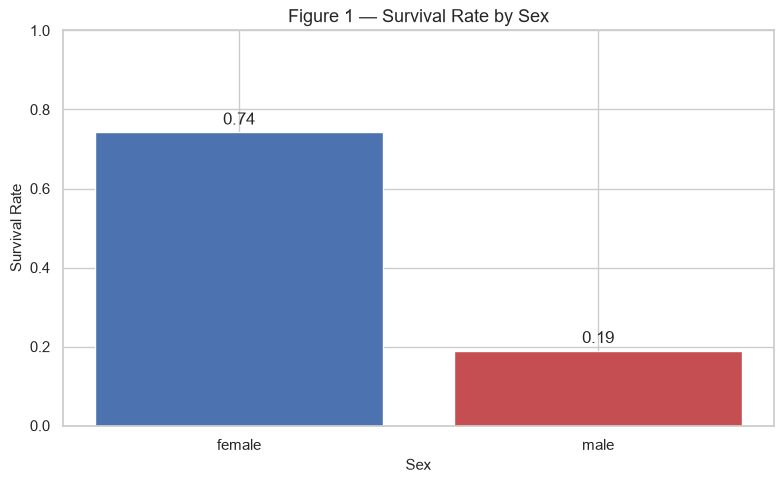

In [8]:
# Figure 1 — Survival rate by sex.
fig, ax = plt.subplots()
rates_sex = df.groupby("Sex")["Survived"].mean()
ax.bar(rates_sex.index, rates_sex.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Figure 1 — Survival Rate by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
for i, v in enumerate(rates_sex.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

**Interpretation (Figure 1):** Sex is the single strongest survival signal in
the dataset. Roughly 74% of women survived versus about 19% of men — a gap
consistent with "women and children first" evacuation priority. Any later
predictive model will lean heavily on this feature.

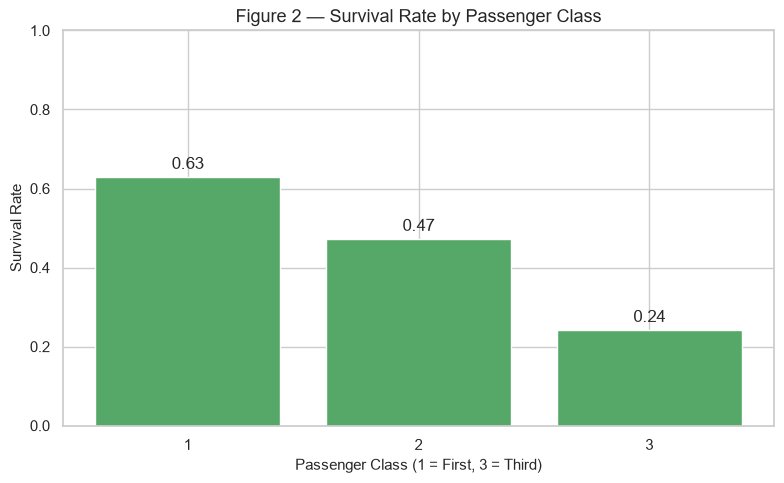

In [9]:
# Figure 2 — Survival rate by passenger class.
fig, ax = plt.subplots()
rates_class = df.groupby("Pclass")["Survived"].mean()
ax.bar(rates_class.index.astype(str), rates_class.values, color="#55A868")
ax.set_title("Figure 2 — Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class (1 = First, 3 = Third)")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
for i, v in enumerate(rates_class.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

**Interpretation (Figure 2):** Survival falls monotonically with class: about
63% in first class, 47% in second, and 24% in third. Class is a proxy for cabin
location, deck access, and social priority during evacuation, so it carries real
signal beyond wealth alone.

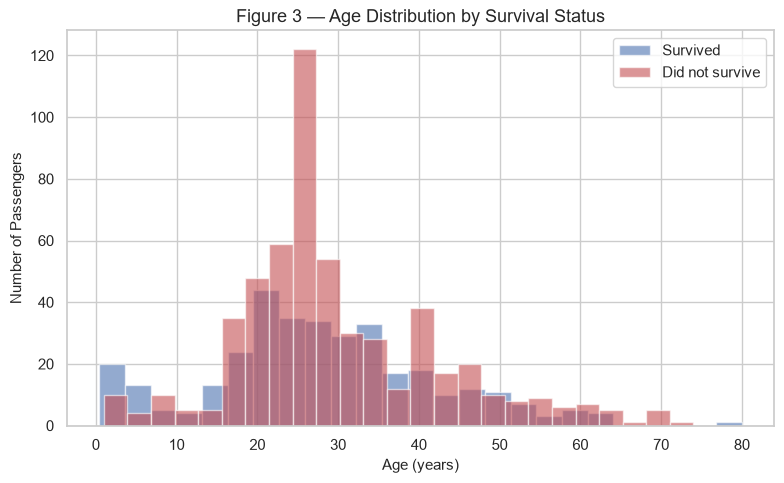

In [10]:
# Figure 3 — Age distribution by survival status.
fig, ax = plt.subplots()
ax.hist(df[df["Survived"] == 1]["Age"], bins=25, alpha=0.6,
        label="Survived", color="#4C72B0")
ax.hist(df[df["Survived"] == 0]["Age"], bins=25, alpha=0.6,
        label="Did not survive", color="#C44E52")
ax.set_title("Figure 3 — Age Distribution by Survival Status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Passengers")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (Figure 3):** The distributions overlap heavily, so age is a
weaker standalone predictor than sex or class. The one visible edge is at the young
end — young children survived at a noticeably higher relative rate — while the large
band of 20–40-year-olds contains most of the non-survivors. The spike created by
grouped-median imputation is visible and is noted as a limitation below.

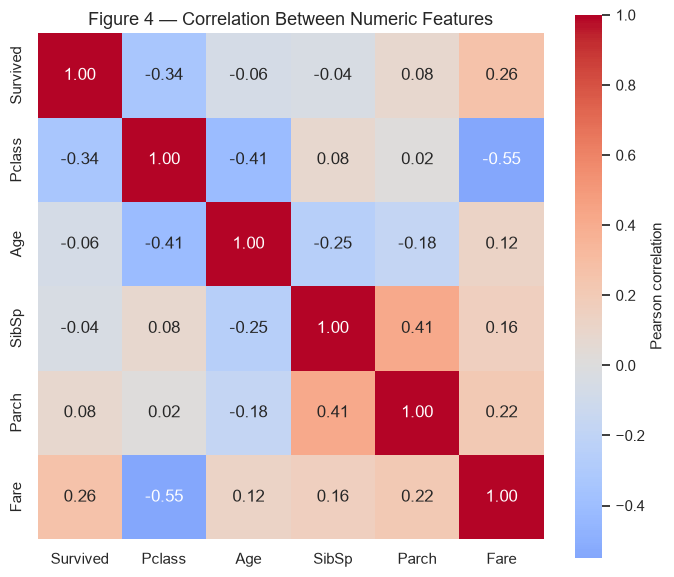

In [11]:
# Figure 4 — Correlation heatmap of numeric features.
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Figure 4 — Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

**Interpretation (Figure 4):** `Fare` correlates positively with survival
(~0.26) and negatively with `Pclass`, which is expected since first-class fares were
higher — the two encode overlapping information. `Pclass` shows the strongest
numeric association with survival (negative: lower class number, higher survival).
The weak inter-correlations among the remaining numeric features suggest they carry
largely independent signal.

## 6. Summary & Interpretation

**What the dataset shows.** Survival on the Titanic was strongly structured, not
random. Sex was the dominant factor (≈74% of women survived vs ≈19% of men),
followed by passenger class, where survival fell steadily from first (≈63%) to
third (≈24%). Fare tracked class and therefore correlated positively with survival.

**Patterns and insights.** The clearest signal is the interaction of social priority
(women and children first) with structural advantage (higher-class passengers had
better deck access and evacuation priority). Age mattered chiefly at the extreme
young end rather than across its whole range.

**Assumptions and limitations.** Age was imputed by Pclass×Sex median, which fills
about a fifth of the column and slightly compresses its natural variance —
concentrating imputed values at group medians (visible in Figure 3). The `Cabin`
column was dropped rather than imputed because it was ~77% empty, which discards any
deck-level signal it might have held. The data covers only passengers with recorded
manifest entries and is a historical snapshot, so conclusions describe *this* event,
not survival in general.

**Surprising / unclear.** The strength and cleanliness of the sex gradient is
striking — few real-world datasets have a single feature this dominant. It is
unclear how much of the class effect is independent of fare versus a restatement of
the same underlying wealth variable; disentangling them would need modeling beyond
this workflow's scope.